In [1]:
import sys
import geopandas as gpd
import r5py
import datetime
from shapely.geometry import Point

sys.argv.append(["--max-memory", "8G"])
print("Libraries imported successfully!")
print(f"Geopandas version: {gpd.__version__}")
print(f"r5py version: {r5py.__version__}")

/Users/pgorn/miniforge3/envs/toronto_access/lib/python3.11/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


Libraries imported successfully!
Geopandas version: 1.1.3
r5py version: 1.1.3


In [ ]:
import h3
from h3 import LatLngPoly
import geopandas as gpd
from shapely.geometry import Polygon

# Toronto bounding box
min_lng, min_lat = -79.639, 43.582
max_lng, max_lat = -79.118, 43.855

# Create LatLngPoly object
outer_ring = [
    (min_lat, min_lng),
    (min_lat, max_lng),
    (max_lat, max_lng),
    (max_lat, min_lng),
    (min_lat, min_lng)
]

polygon = LatLngPoly(outer_ring)

# Get H3 cells at resolution 9
resolution = 9
hex_ids = h3.h3shape_to_cells(polygon, resolution)

print(f"Generated {len(hex_ids)} hex cells")

# Convert to Geo
# 
# Frame
hexagons = []
for hex_id in hex_ids[:10]:  # First 10 as preview
    boundary = h3.cell_to_boundary(hex_id)  # Returns (lat, lng) pairs
    polygon_coords = [(lng, lat) for lat, lng in boundary]  # Convert to (lng, lat)
    hexagons.append({
        "hex_id": hex_id,
        "geometry": Polygon(polygon_coords)
    })

gdf_hex = gpd.GeoDataFrame(hexagons, crs="EPSG:4326")
print(gdf_hex.head())

Generated 11394 hex cells
            hex_id                                           geometry
0  892b986db37ffff  POLYGON ((-79.24784 43.84246, -79.24997 43.841...
1  892b9bc6883ffff  POLYGON ((-79.27542 43.62305, -79.27755 43.621...
2  892b9bcf687ffff  POLYGON ((-79.62089 43.69133, -79.62301 43.690...
3  892b9bc621bffff  POLYGON ((-79.34287 43.67321, -79.345 43.67214...
4  892b9bc0e1bffff  POLYGON ((-79.49481 43.71993, -79.49694 43.718...


In [36]:
# Save as GeoJSON
gdf_hex.to_file("toronto_hexgrid_res9.geojson", driver="GeoJSON")


print("Hex grid saved successfully!")

Hex grid saved successfully!


In [18]:
import sys
import geopandas as gpd
import r5py
import datetime
from shapely.geometry import Point

In [38]:
# Load your Toronto data
osm_path = "data/Toronto.osm.pbf"
gtfs_path = "data/Complete GTFS.zip"

print("Building transport network... (this may take a few minutes)")
transport_network = r5py.TransportNetwork(osm_path, [gtfs_path])

# Load origins (e.g., a grid) and destinations (e.g., libraries)
origins = gpd.read_file("data/toronto_hexgrid_res9.geojson")
libraries = gpd.read_file("data/tpl-branch-general-information - 4326.geojson")

print(f"Network ready! Analyzing {len(origins)} origins and {len(libraries)} destinations.")

Building transport network... (this may take a few minutes)
Network ready! Analyzing 10 origins and 112 destinations.


In [39]:
# Calculate the travel time matrix
travel_time_matrix = r5py.TravelTimeMatrix(
    transport_network,
    origins=origins,
    destinations=libraries,
    transport_modes=[r5py.TransportMode.WALK, r5py.TransportMode.TRANSIT],
    departure=datetime.datetime(2024, 5, 13, 8, 0, 0),
)

# Display the first few rows of the result
print(travel_time_matrix.head())

NoIDColumnError: Data set must contain an 'id' column.

In [40]:
from shapely.geometry import Point, MultiPoint

# ===== FIX LIBRARIES: Safe MultiPoint to Point conversion =====
def extract_point(geom):
    """Safely extract a Point from a Point or MultiPoint geometry"""
    if geom is None or geom.is_empty:
        return None
    elif geom.geom_type == 'Point':
        return geom
    elif geom.geom_type == 'MultiPoint':
        # Return the first point in the MultiPoint
        return geom.geoms[0] if len(geom.geoms) > 0 else None
    else:
        # For any other geometry type, try to get the centroid
        return geom.centroid

# Apply the safe conversion
libraries['geometry'] = libraries['geometry'].apply(extract_point)

# Remove any rows that became None (if any)
before_count = len(libraries)
libraries = libraries.dropna(subset=['geometry'])
after_count = len(libraries)

if before_count != after_count:
    print(f"⚠️ Removed {before_count - after_count} rows with invalid geometries")

# Verify all geometries are now Points
libraries = libraries[libraries.geometry.geom_type == 'Point']
print(f"✅ Libraries: {len(libraries)} point geometries")

# Double-check
print(f"All libraries are Points: {(libraries.geometry.geom_type == 'Point').all()}")

⚠️ Removed 11 rows with invalid geometries
✅ Libraries: 101 point geometries
All libraries are Points: True


In [41]:
# ===== SIMPLEST FIX: Convert everything to centroids =====
# Origins: Convert polygons to centroids
origins['geometry'] = origins.geometry.centroid
origins['id'] = origins['hex_id']

# Libraries: Convert any geometry (Point, MultiPoint, etc.) to centroid
libraries['geometry'] = libraries.geometry.centroid
libraries['id'] = libraries['_id']

# Verify
print(f"✅ Origins: {len(origins)} points, type: {origins.geometry.geom_type.iloc[0]}")
print(f"✅ Libraries: {len(libraries)} points, type: {libraries.geometry.geom_type.iloc[0]}")

# Now calculate travel times
travel_time_matrix = r5py.TravelTimeMatrix(
    transport_network,
    origins=origins.head(10),
    destinations=libraries.head(20),
    transport_modes=[r5py.TransportMode.WALK, r5py.TransportMode.TRANSIT],
    departure=datetime.datetime(2024, 5, 13, 8, 0, 0),
)

print(f"✅ Calculated {len(travel_time_matrix)} travel times")
print(travel_time_matrix.head())

/var/folders/cx/qckjdd7d4b783y6xjpc04zxm0000gn/T/ipykernel_23349/2026277490.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  origins['geometry'] = origins.geometry.centroid
/var/folders/cx/qckjdd7d4b783y6xjpc04zxm0000gn/T/ipykernel_23349/2026277490.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  libraries['geometry'] = libraries.geometry.centroid
/Users/pgorn/miniforge3/envs/toronto_access/lib/python3.11/site-packages/r5py/r5/regional_task.py:205: RuntimeWarning: The currently loaded GTFS data sets do not define any services on 2024-05-13.
  warnings.warn(


✅ Origins: 10 points, type: Point
✅ Libraries: 101 points, type: Point
✅ Calculated 200 travel times
           from_id  to_id  travel_time
0  892b986db37ffff      1          NaN
1  892b986db37ffff      2          NaN
2  892b986db37ffff      3          NaN
3  892b986db37ffff      4          NaN
4  892b986db37ffff      5          NaN


In [42]:
# Find which libraries are reachable from your origins
reachable_libraries = travel_time_matrix.dropna()['to_id'].unique()
unreachable_libraries = set(libraries['id']) - set(reachable_libraries)

print(f"Reachable libraries: {len(reachable_libraries)} out of {len(libraries)}")
print(f"Unreachable libraries: {len(unreachable_libraries)}")

# Show unreachable library IDs
if len(unreachable_libraries) > 0:
    print(f"\nUnreachable library IDs: {sorted(list(unreachable_libraries))[:10]}...")

Reachable libraries: 11 out of 101
Unreachable libraries: 90

Unreachable library IDs: [1, 3, 4, 7, 9, 16, 17, 18, 22, 24]...


In [43]:
# Count libraries reachable within different time thresholds
accessibility = travel_time_matrix.copy()

# Create time buckets
accessibility['time_bucket'] = pd.cut(
    accessibility['travel_time'],
    bins=[0, 15, 30, 45, 60, float('inf')],
    labels=['0-15 min', '15-30 min', '30-45 min', '45-60 min', '60+ min'],
)

# Count per origin
libraries_per_origin = accessibility.groupby('from_id').agg({
    'to_id': 'count',
    'travel_time': lambda x: x.dropna().count()  # Count non-NaN
}).rename(columns={'to_id': 'total_destinations', 'travel_time': 'reachable_destinations'})

# Add reachable within 30 minutes
reachable_30min = accessibility[accessibility['travel_time'] <= 30].groupby('from_id').size()
libraries_per_origin['reachable_within_30min'] = reachable_30min

print("Accessibility by origin:")
print(libraries_per_origin)

Accessibility by origin:
                 total_destinations  reachable_destinations  \
from_id                                                       
892b986db37ffff                  20                       1   
892b9b89393ffff                  20                       0   
892b9bc014bffff                  20                       3   
892b9bc0e1bffff                  20                       4   
892b9bc2817ffff                  20                       3   
892b9bc621bffff                  20                       2   
892b9bc6883ffff                  20                       0   
892b9bcf687ffff                  20                       0   
892b9bd4a87ffff                  20                       4   
892b9bdab57ffff                  20                       0   

                 reachable_within_30min  
from_id                                  
892b986db37ffff                     NaN  
892b9b89393ffff                     NaN  
892b9bc014bffff                     NaN  
892b9bc0

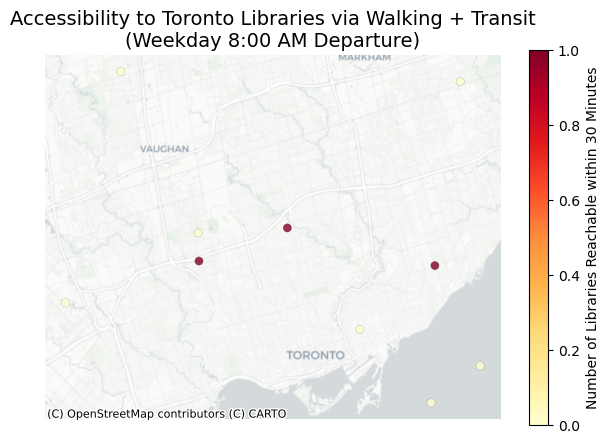

In [44]:
import matplotlib.pyplot as plt
#!pip install contextily 
import contextily as ctx

# Merge accessibility results back to your origins GeoDataFrame
origins_with_access = origins.merge(
    libraries_per_origin[['reachable_within_30min']], 
    left_on='id', 
    right_index=True, 
    how='left'
)

# Fill NaN with 0 (no reachable libraries)
origins_with_access['reachable_within_30min'] = origins_with_access['reachable_within_30min'].fillna(0)

# Create the map
fig, ax = plt.subplots(1, 1, figsize=(6, 5))

# Plot hexagons colored by number of reachable libraries
origins_with_access.plot(
    column='reachable_within_30min',
    cmap='YlOrRd',
    edgecolor='black',
    linewidth=0.1,
    alpha=0.8,
    legend=True,
    ax=ax,
    legend_kwds={
        'label': 'Number of Libraries Reachable within 30 Minutes',
        'orientation': 'vertical',
        'shrink': 0.8
    }
)

# Add basemap (requires contextily: pip install contextily)
try:
    ctx.add_basemap(ax, crs=origins_with_access.crs, source=ctx.providers.CartoDB.Positron)
except:
    print("Basemap not added. Install contextily: pip install contextily")

ax.set_title('Accessibility to Toronto Libraries via Walking + Transit\n(Weekday 8:00 AM Departure)', fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()